In [5]:
import kagglehub
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

In [10]:
path = kagglehub.dataset_download("warcoder/cats-vs-dogs-vs-birds-audio-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cats-vs-dogs-vs-birds-audio-classification' dataset.
Path to dataset files: /kaggle/input/cats-vs-dogs-vs-birds-audio-classification


In [11]:
bird = "/kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/bird"

#Спектрограмма

In [15]:
files = [f for f in os.listdir(bird) if f.endswith('.wav')]

Обрабатываем файл: /kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/bird/84bf12ff_nohash_0.wav


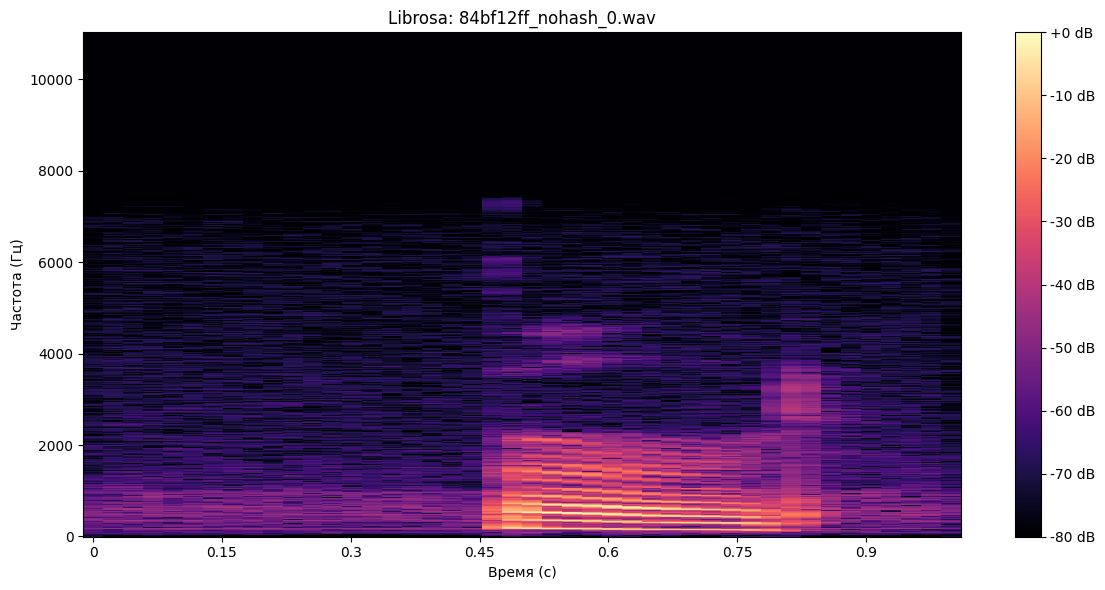

In [16]:
# Librosa
audio_file = os.path.join(bird, files[4])
print(f"Обрабатываем файл: {audio_file}")
y, sr = librosa.load(audio_file, sr=22050, mono=True, duration=5)
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
plt.figure(figsize=(12, 6))
librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Librosa: {files[4]}')
plt.xlabel('Время (с)')
plt.ylabel('Частота (Гц)')
plt.tight_layout()
plt.show()

Обрабатываем файл: /kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/bird/84bf12ff_nohash_0.wav


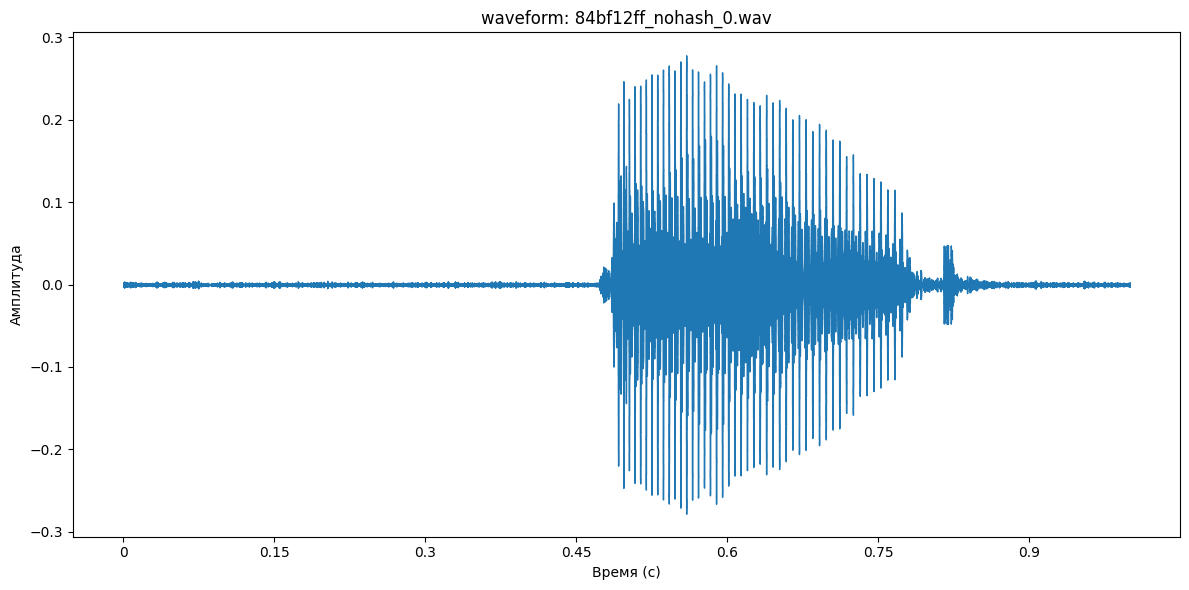

In [17]:
# waveform
audio_file = os.path.join(bird, files[4])
print(f"Обрабатываем файл: {audio_file}")
y, sr = librosa.load(audio_file, duration=5)
plt.figure(figsize=(12, 6))
librosa.display.waveshow(y, sr=sr)
plt.title(f'waveform: {files[4]}')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.tight_layout()
plt.show()

Обрабатываем файл: /kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/bird/84bf12ff_nohash_0.wav


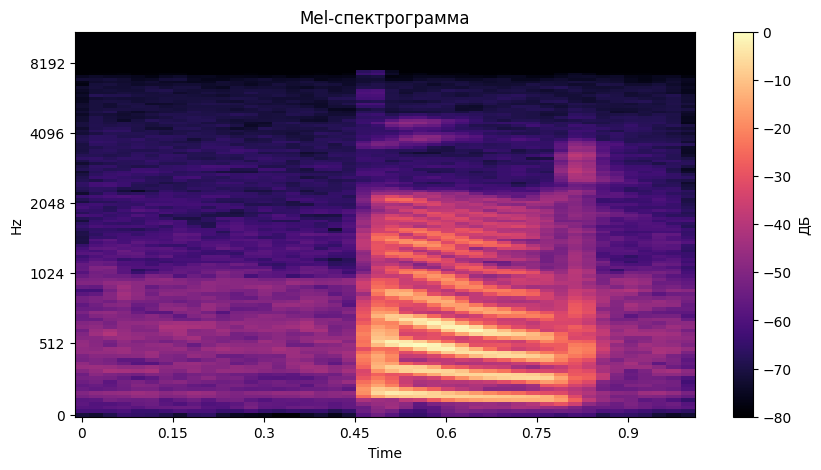

In [18]:
# Mel-спектрограмма
audio_file = os.path.join(bird, files[4])
print(f"Обрабатываем файл: {audio_file}")
S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)
plt.figure(figsize=(10, 5))
librosa.display.specshow(S_mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(label='ДБ')
plt.title('Mel-спектрограмма')
plt.show()

Обрабатываем файл: /kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/bird/84bf12ff_nohash_0.wav


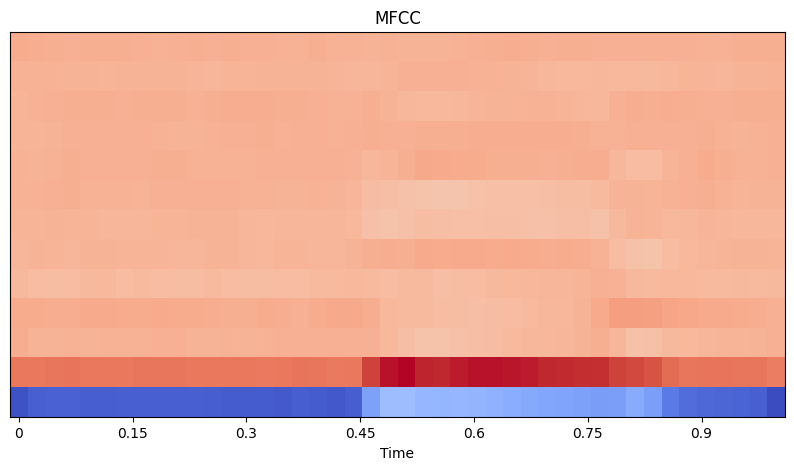

In [19]:
# MFCC
audio_file = os.path.join(bird, files[4])
print(f"Обрабатываем файл: {audio_file}")
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
plt.figure(figsize=(10, 5))
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.title('MFCC')
plt.show()

# Без аугментации random forest / LogisticRegression/ catboost для MFCC

In [26]:
#! pip install catboost

In [27]:
from  glob import glob
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import audiomentations as A


In [28]:
bird = "/kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/bird"

In [29]:
mfccs = librosa.feature.mfcc(y=y, sr=22050, n_mfcc=13)

bird_m = glob('/kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/bird/*.wav')

X_bird = []
Y_bird = []

for i in bird_m:
  y, sr = librosa.load(i, duration=5)
  mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
  X_bird.append(mfccs)
  Y_bird.append('bird')


df_bird = pd.DataFrame({
    'x': [i for i in X_bird],
    'y': [i for i in Y_bird]
})


dog_m = glob('/kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/dog/*.wav')

X_dog = []
Y_dog = []

for i in dog_m:
  y, sr = librosa.load(i, duration=5)
  mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
  X_dog.append(mfccs)
  Y_dog.append('dog')


df_dog = pd.DataFrame({
    'x': [i for i in X_dog],
    'y': [i for i in Y_dog]
})

cat_m = glob('/kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/cat/*.wav')

X_cat = []
Y_cat = []

for i in cat_m:
  y, sr = librosa.load(i, duration=5)
  mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
  X_cat.append(mfccs)
  Y_cat.append('cat')


df_cat = pd.DataFrame({
    'x': [i for i in X_cat],
    'y': [i for i in Y_cat]
})

df = pd.concat([df_cat, df_dog, df_bird], axis=0, ignore_index=True)

In [30]:
X_no_aug = np.array([np.mean(mat, axis=1) for mat in df['x']])
y_no_aug = df['y'].values

label_encoder = LabelEncoder()
y_enc_no_aug = label_encoder.fit_transform(y_no_aug)

X_train, X_test, y_train, y_test = train_test_split(
    X_no_aug, y_enc_no_aug, test_size=0.2, random_state=42, stratify=y_enc_no_aug
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
print("\nRandom Forest")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))


Random Forest
Accuracy: 0.7623
              precision    recall  f1-score   support

        bird       0.85      0.72      0.78        39
         cat       0.78      0.76      0.77        41
         dog       0.69      0.81      0.75        42

    accuracy                           0.76       122
   macro avg       0.77      0.76      0.76       122
weighted avg       0.77      0.76      0.76       122



In [32]:
print("\nLogistic Regression")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))


Logistic Regression
Accuracy: 0.7787
              precision    recall  f1-score   support

        bird       0.86      0.82      0.84        39
         cat       0.74      0.78      0.76        41
         dog       0.74      0.74      0.74        42

    accuracy                           0.78       122
   macro avg       0.78      0.78      0.78       122
weighted avg       0.78      0.78      0.78       122



In [33]:
print("\nCatBoost")
cb_model = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, random_seed=42, verbose=False)
cb_model.fit(X_train, y_train)
y_pred_cb = cb_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_cb):.4f}")
print(classification_report(y_test, y_pred_cb, target_names=label_encoder.classes_))


CatBoost
Accuracy: 0.8033
              precision    recall  f1-score   support

        bird       0.89      0.82      0.85        39
         cat       0.80      0.78      0.79        41
         dog       0.74      0.81      0.77        42

    accuracy                           0.80       122
   macro avg       0.81      0.80      0.81       122
weighted avg       0.81      0.80      0.80       122



# Без аугментации random forest / LogisticRegression/ catboost для waveshow

In [34]:
def load_waveform(file_path, duration=4, sr=22050):
    y, _ = librosa.load(file_path, sr=sr, duration=duration)
    target_len = int(duration * sr)
    if len(y) >= target_len:
        y = y[:target_len]
    else:
        y = np.pad(y, (0, target_len - len(y)), mode='constant')
    return y

cat_paths = glob('/kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/cat/*.wav')
dog_paths = glob('/kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/dog/*.wav')
bird_paths = glob('/kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/bird/*.wav')

X_cat = [load_waveform(p) for p in cat_paths]
X_dog = [load_waveform(p) for p in dog_paths]
X_bird = [load_waveform(p) for p in bird_paths]

df_cat = pd.DataFrame({'x': X_cat, 'y': ['cat']*len(X_cat)})
df_dog = pd.DataFrame({'x': X_dog, 'y': ['dog']*len(X_dog)})
df_bird = pd.DataFrame({'x': X_bird, 'y': ['bird']*len(X_bird)})

df = pd.concat([df_cat, df_dog, df_bird], axis=0, ignore_index=True)

In [35]:
X = np.array([vec for vec in df['x']])
y = df['y'].values

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [36]:
print("\nRandom Forest (waveshow)")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

print("\nLogistic Regression (waveshow)")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

print("\nCatBoost (waveshow)")
cb = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, random_seed=42, verbose=False)
cb.fit(X_train, y_train)
y_pred_cb = cb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_cb):.4f}")
print(classification_report(y_test, y_pred_cb, target_names=label_encoder.classes_))


Random Forest (waveshow)
Accuracy: 0.4426
              precision    recall  f1-score   support

        bird       0.44      0.28      0.34        39
         cat       0.43      0.46      0.45        41
         dog       0.45      0.57      0.51        42

    accuracy                           0.44       122
   macro avg       0.44      0.44      0.43       122
weighted avg       0.44      0.44      0.43       122


Logistic Regression (waveshow)
Accuracy: 0.3525
              precision    recall  f1-score   support

        bird       0.41      0.23      0.30        39
         cat       0.33      0.27      0.30        41
         dog       0.34      0.55      0.42        42

    accuracy                           0.35       122
   macro avg       0.36      0.35      0.34       122
weighted avg       0.36      0.35      0.34       122


CatBoost (waveshow)
Accuracy: 0.3934
              precision    recall  f1-score   support

        bird       0.23      0.13      0.16        39

# Без аугментации random forest / LogisticRegression/ catboost для mel-спектрограммы

In [37]:
DURATION = 5
SR = 22050
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048

TARGET_TIME_FRAMES = (DURATION * SR) // HOP_LENGTH

def get_mel_flat(file_path):
    y, sr = librosa.load(file_path, sr=SR, duration=DURATION)
    mel_spec = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    if mel_db.shape[1] >= TARGET_TIME_FRAMES:
        mel_db = mel_db[:, :TARGET_TIME_FRAMES]
    else:
        pad_width = ((0, 0), (0, TARGET_TIME_FRAMES - mel_db.shape[1]))
        mel_db = np.pad(mel_db, pad_width, mode='constant')
    return mel_db.flatten()

In [38]:
cat_paths = glob('/kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/cat/*.wav')
dog_paths = glob('/kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/dog/*.wav')
bird_paths = glob('/kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/bird/*.wav')

X_cat = [get_mel_flat(p) for p in cat_paths]
X_dog = [get_mel_flat(p) for p in dog_paths]
X_bird = [get_mel_flat(p) for p in bird_paths]

df_cat = pd.DataFrame({'x': X_cat, 'y': ['cat']*len(X_cat)})
df_dog = pd.DataFrame({'x': X_dog, 'y': ['dog']*len(X_dog)})
df_bird = pd.DataFrame({'x': X_bird, 'y': ['bird']*len(X_bird)})

df = pd.concat([df_cat, df_dog, df_bird], axis=0, ignore_index=True)

In [39]:
X = np.array([vec for vec in df['x']])
y = df['y'].values

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
print("\nRandom Forest (mel-spectrogram)")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

print("\nLogistic Regression (mel-spectrogram)")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

print("\nCatBoost (mel-spectrogram)")
cb = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, random_seed=42, verbose=False)
cb.fit(X_train, y_train)
y_pred_cb = cb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_cb):.4f}")
print(classification_report(y_test, y_pred_cb, target_names=label_encoder.classes_))


Random Forest (mel-spectrogram)
Accuracy: 0.7951
              precision    recall  f1-score   support

        bird       0.93      0.72      0.81        39
         cat       0.76      0.93      0.84        41
         dog       0.74      0.74      0.74        42

    accuracy                           0.80       122
   macro avg       0.81      0.79      0.79       122
weighted avg       0.81      0.80      0.79       122


Logistic Regression (mel-spectrogram)
Accuracy: 0.8197
              precision    recall  f1-score   support

        bird       0.86      0.82      0.84        39
         cat       0.80      0.85      0.82        41
         dog       0.80      0.79      0.80        42

    accuracy                           0.82       122
   macro avg       0.82      0.82      0.82       122
weighted avg       0.82      0.82      0.82       122


CatBoost (mel-spectrogram)
Accuracy: 0.8361
              precision    recall  f1-score   support

        bird       0.94      0.7

# С аугментацией

In [47]:
base = '/kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals'
cat_files = glob(f'{base}/cat/*.wav')
dog_files = glob(f'{base}/dog/*.wav')
bird_files = glob(f'{base}/bird/*.wav')

all_paths = cat_files + dog_files + bird_files
all_labels = ['cat']*len(cat_files) + ['dog']*len(dog_files) + ['bird']*len(bird_files)

In [49]:
augmenter = A.Compose([
    A.AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    A.PitchShift(min_semitones=-2, max_semitones=2, p=0.5),
    A.TimeStretch(min_rate=0.8, max_rate=1.25, p=0.5),
])

DURATION = 3
SR = 22050
N_MFCC = 13
N_MELS = 128
HOP_LENGTH = 512


In [50]:
signals = []      # каждый элемент – аугментированный массив y
labels = []

for path, label in zip(all_paths, all_labels):
    y_orig, sr = librosa.load(path, sr=SR, duration=DURATION)

    signals.append(y_orig)
    labels.append(label)

    for _ in range(2):
        y_aug = augmenter(samples=y_orig, sample_rate=sr)
        signals.append(y_aug)
        labels.append(label)

In [51]:
print(f"Всего сигналов после аугментации: {len(signals)}")

Всего сигналов после аугментации: 1830


In [52]:
# waveform
target_len = DURATION * SR
X_wav = []
for y in signals:
    if len(y) >= target_len:
        wav = y[:target_len]
    else:
        wav = np.pad(y, (0, target_len - len(y)))
    X_wav.append(wav)

# MFCC – усреднённый по времени
X_mfcc = []
for y in signals:
    m = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC)
    X_mfcc.append(np.mean(m, axis=1))

# mel-спектрограммы – логарифм
target_frames = int(DURATION * SR / HOP_LENGTH)
X_mel = []
for y in signals:
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] >= target_frames:
        mel_db = mel_db[:, :target_frames]
    else:
        pad_width = ((0, 0), (0, target_frames - mel_db.shape[1]))
        mel_db = np.pad(mel_db, pad_width, mode='constant')
    X_mel.append(mel_db.flatten())

In [54]:
X_wav = np.array(X_wav)
X_mfcc = np.array(X_mfcc)
X_mel = np.array(X_mel)
y = np.array(labels)

print(f"Waveform: {X_wav.shape}")
print(f"MFCC: {X_mfcc.shape}")
print(f"Mel: {X_mel.shape}")

Waveform: (1830, 66150)
MFCC: (1830, 13)
Mel: (1830, 16512)


In [55]:
def train_models(X, y, model_name):
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train.astype(np.float32))
    X_test_scaled = scaler.transform(X_test.astype(np.float32))

    print(f"\n{'='*20} {model_name} {'='*20}")

    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    y_pred = lr.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"Logistic Regression | Accuracy: {acc:.4f}")

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Random Forest      | Accuracy: {acc:.4f}")

    # CatBoost
    cb = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, random_seed=42, verbose=False)
    cb.fit(X_train, y_train)
    y_pred = cb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"CatBoost           | Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

In [56]:
train_models(X_mfcc, y, "MFCC")
train_models(X_wav, y, "Waveform")
train_models(X_mel, y, "Mel-spectrogram")


==================== MFCC ====================
Logistic Regression | Accuracy: 0.8060
Random Forest      | Accuracy: 0.8907
CatBoost           | Accuracy: 0.8743
              precision    recall  f1-score   support

        bird       0.89      0.85      0.87       116
         cat       0.90      0.90      0.90       124
         dog       0.84      0.87      0.85       126

    accuracy                           0.87       366
   macro avg       0.88      0.87      0.87       366
weighted avg       0.87      0.87      0.87       366


==================== Waveform ====================
Logistic Regression | Accuracy: 0.5738
Random Forest      | Accuracy: 0.6202
CatBoost           | Accuracy: 0.6011
              precision    recall  f1-score   support

        bird       0.64      0.53      0.58       116
         cat       0.59      0.64      0.61       124
         dog       0.58      0.63      0.61       126

    accuracy                           0.60       366
   macro avg     